<a href="https://colab.research.google.com/github/igorcsdalmeida-dev/projeto-mineracao-dados-eleitorais-2026/blob/main/02_clusterizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 2 — Clusterização: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Existem perfis demográfico-sociais distintos entre os candidatos, nas Eleições 2026? Combinando idade, escolaridade e patrimônio declarado, os candidatos se agrupam em segmentos claramente diferentes — e, se sim, como esses segmentos se distribuem em termos de gênero, cor/raça e estado civil?**

Para responder isso com K-Means, separamos as variáveis em dois papéis:

- **Variáveis-driver** (entram na conta de distância, definem os clusters): idade, escolaridade e patrimônio declarado.
- **Variáveis de perfil** (não entram no modelo — descrevem os clusters depois de prontos): `DS_GENERO`, `DS_COR_RACA`, `DS_ESTADO_CIVIL`.

> `DS_SIT_TOT_TURNO` (situação eleitoral — eleito ou não) fica de fora por enquanto: a eleição de 2026 ainda não aconteceu, então essa coluna vem toda nula nesta base. Assim que o resultado sair, vale voltar aqui e cruzar os clusters com quem foi eleito.

Essa separação importa: jogar categóricas como gênero/raça direto numa distância Euclidiana exigiria codificação cuidadosa (fora do escopo desta primeira versão). Em vez disso, os grupos nascem de 3 variáveis contínuas/ordinais bem comportadas, e o "perfil demográfico-social" completo — que é o que a pergunta pede — aparece na leitura dos clusters, não na formação deles.

**Este notebook cobre a Parte 1 (K-Means)**, em **duas rodadas de propósito**, pra mostrar por que escolha de variável e escolha de métrica importam:

1. **Versão 1**: exatamente como fizemos na primeira tentativa — escolaridade entra como o código bruto do TSE, seleção de `k` só com cotovelo + silhouette.
2. **Versão 2**: escolaridade recodificada como variável intervalar, e mais duas métricas (Davies-Bouldin, Calinski-Harabasz) apoiando a escolha de `k`.

DBSCAN, hierárquico e Bisecting K-Means serão adicionados nas próximas atualizações, reaproveitando a mesma base e a mesma pergunta.

Parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

Use os **mesmos valores** que você usou na Fase 0/1, para carregar o arquivo certo.

In [13]:
CARGO = "SENADOR"   # mesmo valor usado na Fase 0/1
UF = None               # mesmo valor usado na Fase 0/1
ANO_ELEICAO = 2026

In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)  # reprodutibilidade defensiva — o KMeans já usa random_state próprio,
                          # mas fixar a semente global evita surpresa se alguém adicionar
                          # outro trecho aleatório (amostragem, shuffle, etc.) mais adiante.

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_SENADOR_BRASIL_2026.csv  ->  319 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,01/09/2026,12:31:01,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002533895,100,CYLMARA FERNANDES DA ROCHA GRIPP,MARA ROCHA,#NULO,41186273291,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,10,REPUBLICANOS,REPUBLICANOS,-1,#NULO,#NULO,#NULO,10001800117,TRABALHO DA ESPERANÇA,REPUBLICANOS / PSD / AVANTE / NOVO,AC,1973-09-04,2324422437,4,FEMININO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,53
1,01/09/2026,12:31:01,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002535804,555,SERGIO DE OLIVEIRA CUNHA,PETECÃO,#NULO,9604332287,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,55,PSD,PARTIDO SOCIAL DEMOCRÁTICO,-1,#NULO,#NULO,#NULO,10001800117,TRABALHO DA ESPERANÇA,REPUBLICANOS / PSD / AVANTE / NOVO,AC,1960-04-20,825962445,2,MASCULINO,6,ENSINO MÉDIO COMPLETO,3,CASADO(A),3,PARDA,257,EMPRESÁRIO,-1,#NULO,2328619.58,1085051.0,0.00,44810.00,0.00,403114.28,3861594.86,15.166591,66
2,01/09/2026,12:31:01,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002536441,131,JORGE NEY VIANA MACEDO NEVES,JORGE VIANA,#NULO,96980486853,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,13,PT,PARTIDO DOS TRABALHADORES,101,FEDERAÇÃO BRASIL DA ESPERANÇA - FE BRASIL,PT/PC do B/PV,PT/PC do B/PV,10001800264,FRENTE AMPLA PELO ACRE,PODE / PSB / FEDERAÇÃO BRASIL DA ESPERANÇA - F...,AC,1959-09-20,780342402,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),3,PARDA,101,ENGENHEIRO,-1,#NULO,4699419.72,0.0,41923.19,154880.55,159441.62,520126.80,5575791.88,15.533945,67
3,01/09/2026,12:31:01,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002536710,277,RIBAMAR DE SOUSA FEITOZA JÚNIOR,DR. JUNIOR FEITOSA,#NULO,67146902234,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,27,DC,DEMOCRACIA CRISTÃ,-1,#NULO,#NULO,#NULO,10001800309,PARTIDO ISOLADO,DC,AC,1982-05-09,3576712402,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),3,PARDA,131,ADVOGADO,-1,#NULO,0.00,464000.0,0.00,0.00,0.00,888418.21,1352418.21,14.117406,44
4,01/09/2026,12:31:01,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002544110,500,INACIO ALVES MOREIRA NETTO,PROFESSOR INACIO MOREIRA,#NULO,32218893215,NÃO DIVULGÁVEL,-3,#NE,FEDERAÇÃO,50,PSOL,PARTIDO SOCIALISMO E LIBERDADE,102,FEDERAÇÃO PSOL REDE,PSOL/REDE,PSOL/REDE,10001800655,FEDERAÇÃO,FEDERAÇÃO PSOL REDE (PSOL / REDE),AC,1970-05-14,1440942429,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),2,PRETA,265,PROFESSOR DE ENSINO FUNDAMENTAL,-1,#NULO,200000.00,0.0,0.00,0.00,0.00,0.00,200000.00,12.206078,56


---
# Versão 1 — a primeira tentativa

Variáveis-driver: `IDADE`, `CD_GRAU_INSTRUCAO` (código bruto do TSE, 2 a 8), `Total_Bens_Log`. Escolha de `k` só com cotovelo (WCSS) + silhouette.

### V1.1) Outliers e padronização

In [15]:
colunas_driver_v1 = ['IDADE', 'CD_GRAU_INSTRUCAO', 'Total_Bens_Log']

antes = df.shape[0]
Q1, Q3 = df['Total_Bens_Log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_cluster_v1 = df[df['Total_Bens_Log'] <= limite_superior].copy()
print(f"Removidos {antes - df_cluster_v1.shape[0]} candidatos com patrimônio extremo "
      f"(Total_Bens_Log > {limite_superior:.2f}, ~R$ {np.expm1(limite_superior):,.0f})")
print(f"Base para clusterização: {df_cluster_v1.shape[0]} candidatos")

scaler_v1 = MinMaxScaler()
X_v1 = scaler_v1.fit_transform(df_cluster_v1[colunas_driver_v1])

df_cluster_v1[colunas_driver_v1].describe()

Removidos 2 candidatos com patrimônio extremo (Total_Bens_Log > 19.48, ~R$ 288,680,973)
Base para clusterização: 317 candidatos


,IDADE,CD_GRAU_INSTRUCAO,Total_Bens_Log
count,317.000000,317.000000,317.000000
mean,55.422713,7.611987,11.455328
std,11.306064,0.884598,5.384730
min,35.000000,2.000000,0.000000
25%,46.000000,8.000000,11.512935
50%,56.000000,8.000000,13.393065
75%,64.000000,8.000000,14.677554
max,92.000000,8.000000,18.022889


### V1.2) Escolhendo k (cotovelo + silhouette)

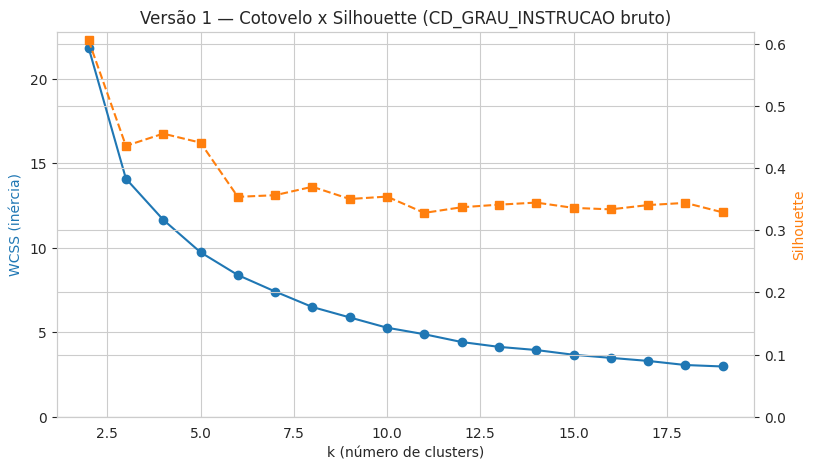

k=2  WCSS=21.846  silhouette=0.605
k=3  WCSS=14.091  silhouette=0.435
k=4  WCSS=11.659  silhouette=0.455
k=5  WCSS=9.735  silhouette=0.441
k=6  WCSS=8.388  silhouette=0.354
k=7  WCSS=7.411  silhouette=0.356
k=8  WCSS=6.493  silhouette=0.370
k=9  WCSS=5.878  silhouette=0.350
k=10  WCSS=5.270  silhouette=0.354
k=11  WCSS=4.883  silhouette=0.328
k=12  WCSS=4.422  silhouette=0.337
k=13  WCSS=4.135  silhouette=0.341
k=14  WCSS=3.948  silhouette=0.344
k=15  WCSS=3.668  silhouette=0.336
k=16  WCSS=3.484  silhouette=0.333
k=17  WCSS=3.303  silhouette=0.340
k=18  WCSS=3.061  silhouette=0.344
k=19  WCSS=2.974  silhouette=0.329


In [16]:
wcss_v1, sil_v1 = [], []
faixa_k = range(2, 20)

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X_v1)
    wcss_v1.append(km.inertia_)
    sil_v1.append(silhouette_score(X_v1, labels))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(list(faixa_k), wcss_v1, marker='o', color='tab:blue')
ax1.set_xlabel('k (número de clusters)')
ax1.set_ylabel('WCSS (inércia)', color='tab:blue')
ax1.set_ylim(bottom=0)  # eixo começa em zero: um eixo cortado pode fazer o cotovelo parecer mais dramático do que é
ax1.set_title('Versão 1 — Cotovelo x Silhouette (CD_GRAU_INSTRUCAO bruto)')

ax2 = ax1.twinx()
ax2.plot(list(faixa_k), sil_v1, marker='s', linestyle='--', color='tab:orange')
ax2.set_ylabel('Silhouette', color='tab:orange')
ax2.set_ylim(bottom=min(0, min(sil_v1)))
plt.show()

for k, w, s in zip(faixa_k, wcss_v1, sil_v1):
    print(f"k={k}  WCSS={w:.3f}  silhouette={s:.3f}")

> Repare que o cotovelo não mostra uma quebra nítida — a curva desce suavemente, sem um "V" claro. Isso pode ser dado real (candidatos formando mais um contínuo do que grupos separados) ou pode ser efeito de tratar uma variável ordinal como se fosse intervalar. Seguimos mesmo assim com um `k` razoável, só pra completar a Versão 1 e comparar depois.

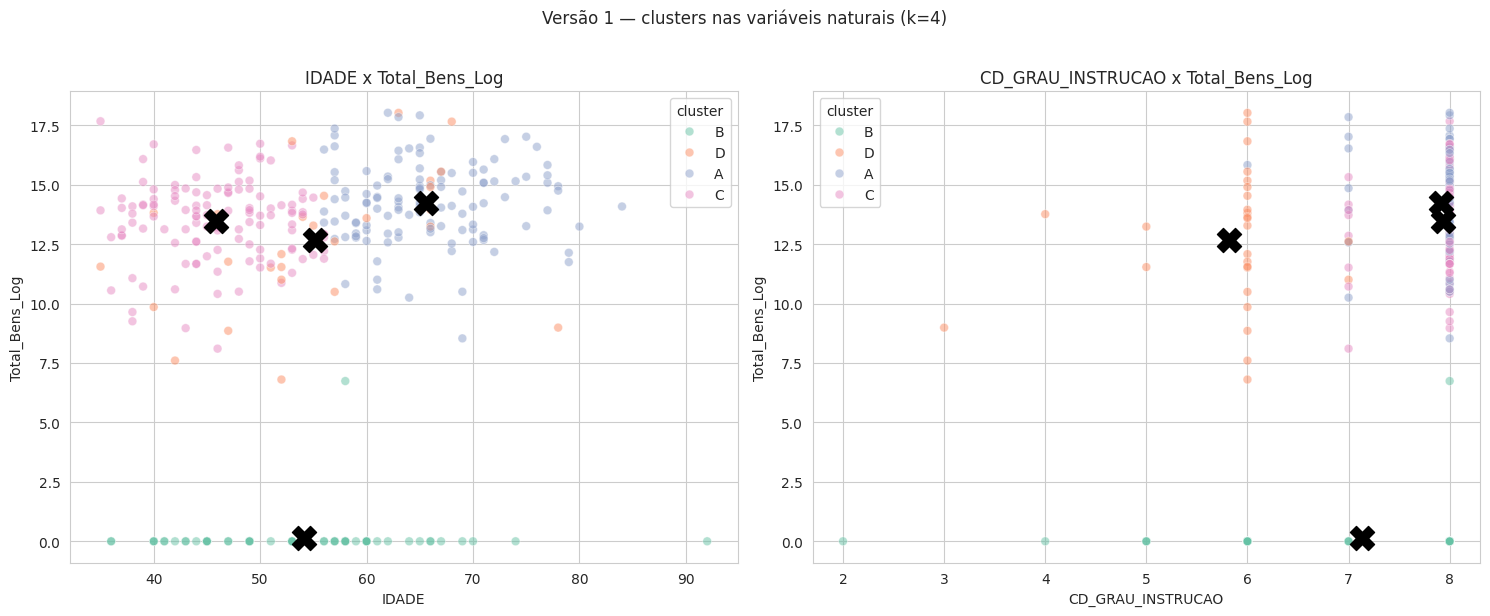

,qtd_candidatos,idade_media,instrucao_media,patrimonio_mediano
cluster,,,,
A,117,65.7,7.9,1516039.0
B,53,54.1,7.1,0.0
C,120,46.0,7.9,904280.5
D,27,55.1,5.8,560000.0


In [17]:
k_v1 = 4  # ajuste conforme a célula anterior, se quiser

kmeans_v1 = KMeans(n_clusters=k_v1, random_state=SEMENTE, n_init=10)
df_cluster_v1['cluster'] = kmeans_v1.fit_predict(X_v1)
df_cluster_v1['cluster'] = df_cluster_v1['cluster'].map(lambda x: chr(65 + x))

centroides_v1 = scaler_v1.inverse_transform(kmeans_v1.cluster_centers_)
df_centroides_v1 = pd.DataFrame(centroides_v1, columns=colunas_driver_v1)
df_centroides_v1.index = [chr(65 + i) for i in range(k_v1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_cluster_v1, x='IDADE', y='Total_Bens_Log', hue='cluster', palette='Set2', alpha=0.5, s=40, ax=axes[0])
axes[0].scatter(df_centroides_v1['IDADE'], df_centroides_v1['Total_Bens_Log'], marker='X', s=300, c='black')
axes[0].set_title('IDADE x Total_Bens_Log')

sns.scatterplot(data=df_cluster_v1, x='CD_GRAU_INSTRUCAO', y='Total_Bens_Log', hue='cluster', palette='Set2', alpha=0.5, s=40, ax=axes[1])
axes[1].scatter(df_centroides_v1['CD_GRAU_INSTRUCAO'], df_centroides_v1['Total_Bens_Log'], marker='X', s=300, c='black')
axes[1].set_title('CD_GRAU_INSTRUCAO x Total_Bens_Log')

plt.suptitle(f'Versão 1 — clusters nas variáveis naturais (k={k_v1})', y=1.02)
plt.tight_layout()
plt.show()

resumo_v1 = df_cluster_v1.groupby('cluster').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    instrucao_media=('CD_GRAU_INSTRUCAO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_v1)

---
# Versão 2 — ajustando a variável e a métrica

Dois ajustes em relação à Versão 1:

1. **Escolaridade como variável intervalar.** `CD_GRAU_INSTRUCAO` é um código **ordinal**, não intervalar: nada garante que o "salto" entre dois códigos consecutivos valha o mesmo em todos os pontos da escala (a diferença entre "lê e escreve" e "fundamental incompleto" não é comparável à diferença entre "superior incompleto" e "superior completo"). Como o K-Means calcula médias e distância Euclidiana, ele *assume* espaçamento igual — então usar o código bruto distorce essa variável. Trocamos pelo proxy padrão em pesquisa social: **anos de escolaridade equivalentes** (mesma lógica usada em censos/pesquisas domiciliares).
2. **Mais métricas para escolher `k`.** Além de WCSS e silhouette, adicionamos Davies-Bouldin e Calinski-Harabasz — quando o cotovelo é ambíguo (como foi o caso), várias métricas concordando é um sinal mais forte do que uma métrica só.

In [18]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — não dá pra estimar anos de estudo sem essa informação
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)

print("Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar):", df['ANOS_ESTUDO'].isna().sum())
df[['DS_GRAU_INSTRUCAO', 'ANOS_ESTUDO']].drop_duplicates().sort_values('ANOS_ESTUDO')

Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar): 0


,DS_GRAU_INSTRUCAO,ANOS_ESTUDO
26,LÊ E ESCREVE,1
164,ENSINO FUNDAMENTAL INCOMPLETO,4
107,ENSINO FUNDAMENTAL COMPLETO,8
10,ENSINO MÉDIO INCOMPLETO,9
1,ENSINO MÉDIO COMPLETO,11
9,SUPERIOR INCOMPLETO,13
0,SUPERIOR COMPLETO,16


> **Alternativa mais rigorosa (fora do escopo desta primeira versão):** distância de **Gower** — que trata variáveis ordinais, nominais e contínuas de forma nativa, sem forçar nenhuma delas a um espaçamento artificial — combinada com **K-Medoids/PAM** em vez de K-Means (Gower não permite calcular "média", só distância entre pontos reais). Fica como comparação futura, ao lado de DBSCAN/hierárquico/Bisecting K-Means.

### V2.1) Outliers e padronização

In [19]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']

antes = df.shape[0]
df_cluster = df[(df['Total_Bens_Log'] <= limite_superior) & (df['ANOS_ESTUDO'].notna())].copy()
print(f"Removidos {antes - df_cluster.shape[0]} candidatos "
      f"(patrimônio extremo acima de ~R$ {np.expm1(limite_superior):,.0f}, ou escolaridade não divulgada)")
print(f"Base para clusterização: {df_cluster.shape[0]} candidatos")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])

df_cluster[colunas_driver].describe()

Removidos 2 candidatos (patrimônio extremo acima de ~R$ 288,680,973, ou escolaridade não divulgada)
Base para clusterização: 317 candidatos


,IDADE,ANOS_ESTUDO,Total_Bens_Log
count,317.000000,317.000000,317.000000
mean,55.422713,15.018927,11.455328
std,11.306064,2.161140,5.384730
min,35.000000,1.000000,0.000000
25%,46.000000,16.000000,11.512935
50%,56.000000,16.000000,13.393065
75%,64.000000,16.000000,14.677554
max,92.000000,16.000000,18.022889


### V2.2) Escolhendo k (cotovelo + silhouette + Davies-Bouldin + Calinski-Harabasz)

- **Silhouette** (quanto maior, melhor).
- **Davies-Bouldin** (quanto **menor**, melhor): quão parecidos/sobrepostos os clusters são entre si.
- **Calinski-Harabasz** (quanto maior, melhor): razão entre dispersão entre clusters e dispersão dentro dos clusters.

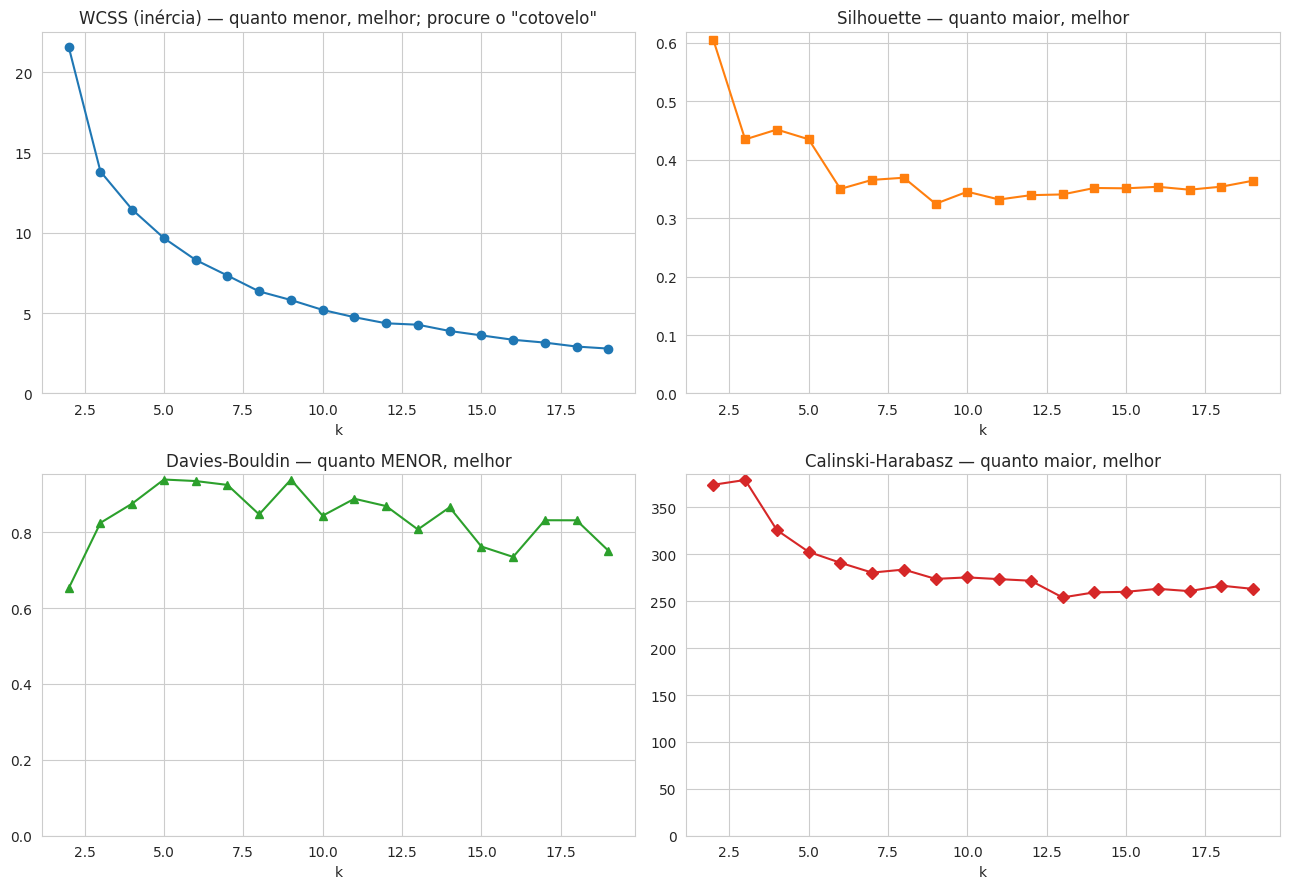

,k,wcss,silhouette,davies_bouldin,calinski_harabasz
0,2,21.573,0.605,0.652,374.201
1,3,13.817,0.435,0.824,379.333
2,4,11.448,0.451,0.875,325.846
3,5,9.671,0.435,0.939,302.680
4,6,8.311,0.350,0.935,291.025
5,7,7.341,0.365,0.924,280.543
6,8,6.353,0.369,0.847,283.800
7,9,5.818,0.324,0.938,273.833
8,10,5.201,0.345,0.843,275.439
9,11,4.748,0.332,0.888,273.578


In [20]:
wcss, sil, db, ch = [], [], [], []

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X, labels))
    db.append(davies_bouldin_score(X, labels))
    ch.append(calinski_harabasz_score(X, labels))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(list(faixa_k), wcss, marker='o', color='tab:blue')
axes[0, 0].set_title('WCSS (inércia) — quanto menor, melhor; procure o "cotovelo"')
axes[0, 0].set_ylim(bottom=0)

axes[0, 1].plot(list(faixa_k), sil, marker='s', color='tab:orange')
axes[0, 1].set_title('Silhouette — quanto maior, melhor')
axes[0, 1].set_ylim(bottom=min(0, min(sil)))

axes[1, 0].plot(list(faixa_k), db, marker='^', color='tab:green')
axes[1, 0].set_title('Davies-Bouldin — quanto MENOR, melhor')
axes[1, 0].set_ylim(bottom=0)

axes[1, 1].plot(list(faixa_k), ch, marker='D', color='tab:red')
axes[1, 1].set_title('Calinski-Harabasz — quanto maior, melhor')
axes[1, 1].set_ylim(bottom=0)

# eixo em zero: evita que um eixo cortado exagere visualmente uma quebra que não é tão forte assim
for ax in axes.flatten():
    ax.set_xlabel('k')
    ax.grid(True)

plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(faixa_k), 'wcss': wcss, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}).round(3)

### V2.3) Ajustando o K-Means

Escolha o `k` cruzando as quatro métricas acima — se elas discordarem muito, prefira o `k` mais fácil de interpretar/explicar dentro da pergunta de negócio.

In [21]:
k_final = 4  # ajuste conforme a célula anterior

kmeans = KMeans(n_clusters=k_final, random_state=SEMENTE, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X)
df_cluster['cluster'] = df_cluster['cluster'].map(lambda x: chr(65 + x))

# Paleta única e fixa por cluster — reaproveitada em TODOS os gráficos daqui pra frente,
# pra cluster A ter sempre a mesma cor, em qualquer tipo de gráfico (scatter, barra, radar...).
clusters_ordenados = sorted(df_cluster['cluster'].unique())
cores_cluster = dict(zip(clusters_ordenados, sns.color_palette('Set2', n_colors=len(clusters_ordenados))))

df_cluster['cluster'].value_counts().sort_index()

,count
cluster,
A,30
B,120
C,53
D,114


In [22]:
resumo_driver = df_cluster.groupby('cluster').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_driver)

centroides_norm = kmeans.cluster_centers_
centroides_naturais = scaler.inverse_transform(centroides_norm)
df_centroides = pd.DataFrame(centroides_naturais, columns=colunas_driver)
df_centroides.index = [chr(65 + i) for i in range(k_final)]
df_centroides.index.name = 'cluster'
df_centroides.round(1)

,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster,,,,
A,30,54.7,10.9,232000.0
B,120,46.2,15.8,920662.2
C,53,54.1,13.9,0.0
D,114,66.0,15.8,1684036.7


,IDADE,ANOS_ESTUDO,Total_Bens_Log
cluster,,,
A,54.7,10.9,12.2
B,46.2,15.8,13.5
C,54.1,13.9,0.1
D,66.0,15.8,14.3


### Radar: todos os clusters juntos, e depois um a um

Primeiro, todos os clusters sobrepostos no mesmo radar — bom pra comparar formatos de relance. Logo abaixo, o mesmo radar **separado por cluster** — mais fácil de ler o formato de cada um sem o excesso de linhas sobrepostas. As duas versões usam os centróides **na escala padronizada (0 a 1)**, que é o que torna os 3 eixos comparáveis entre si.

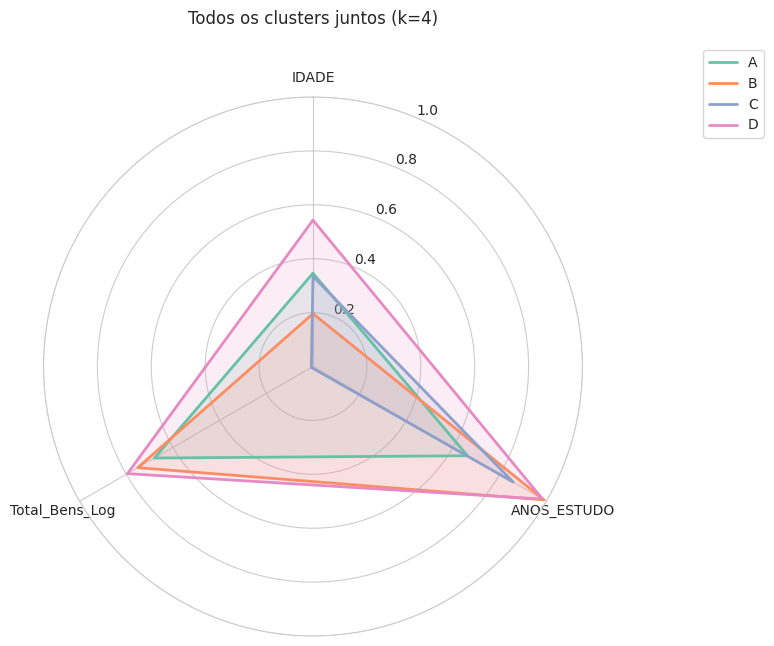

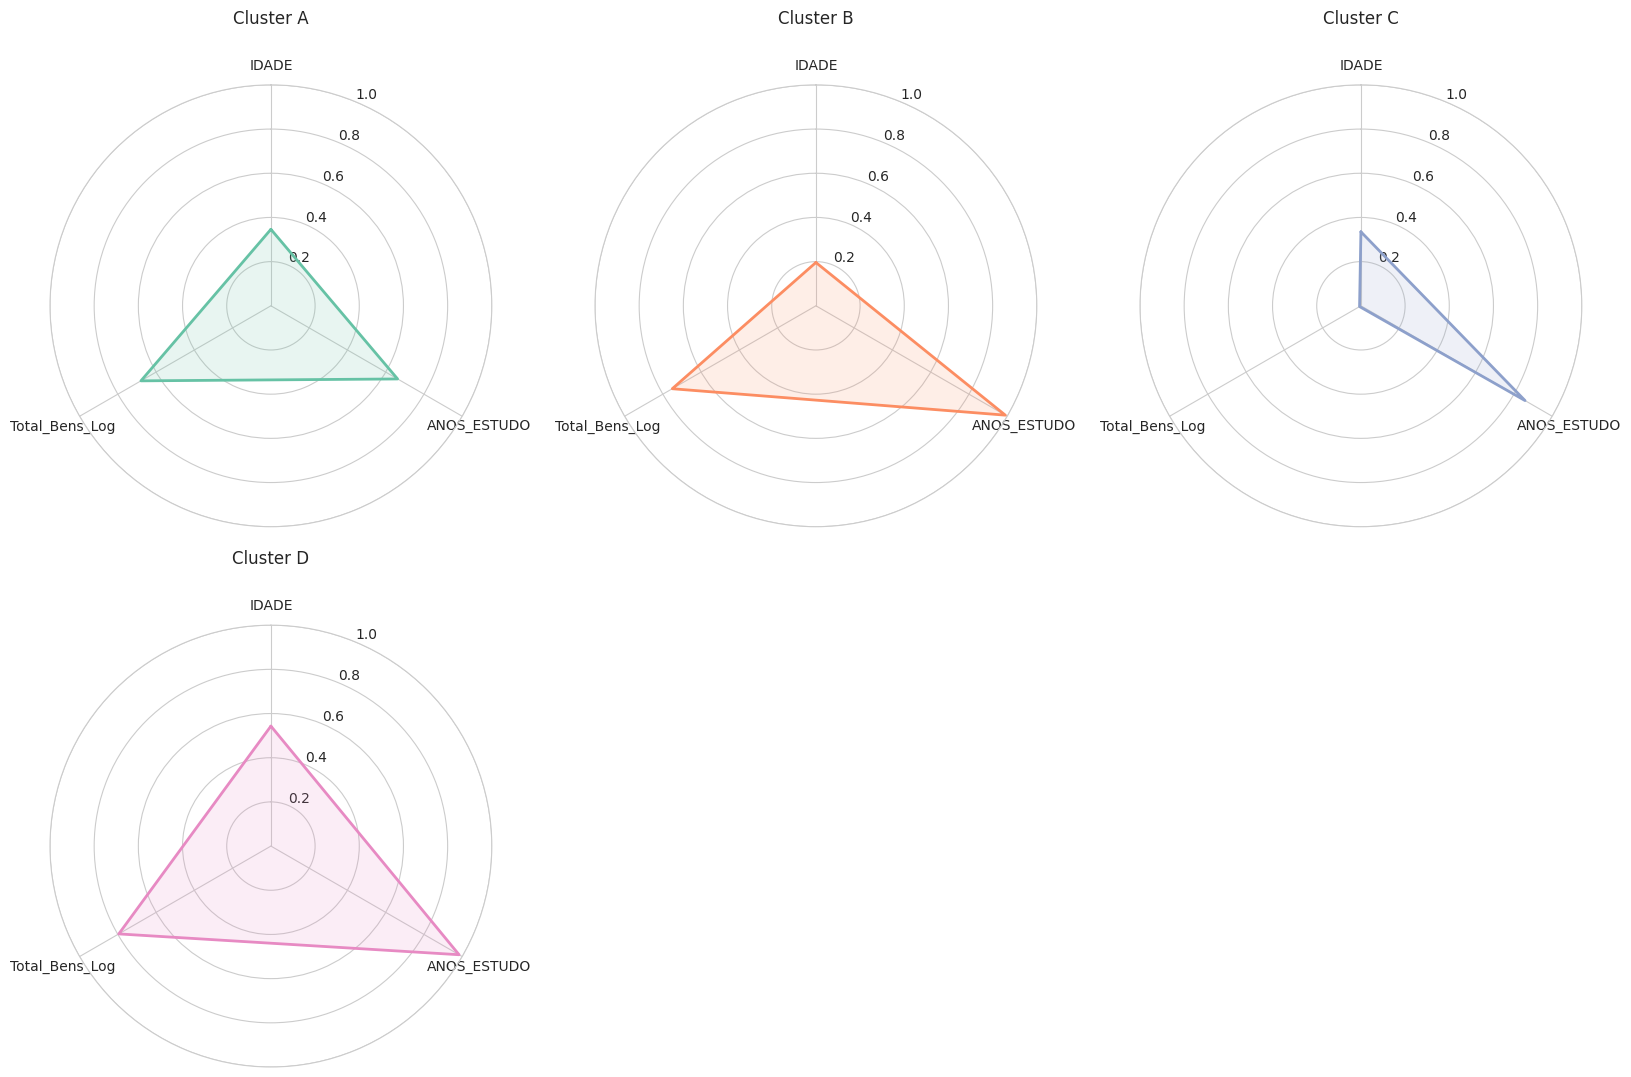

In [23]:
from math import pi

def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)
    angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)
    ax.set_ylim(0, 1)

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]
        ax.plot(angulos, valores, linewidth=2, label=labels_series[i], color=cor)
        ax.fill(angulos, valores, alpha=0.15, color=cor)

    ax.set_title(titulo, y=1.12)

# --- todos juntos ---
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
plot_radar(ax, centroides_norm, colunas_driver, clusters_ordenados, cores_cluster,
           f'Todos os clusters juntos (k={k_final})')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

# --- um radar por cluster ---
ncols = min(k_final, 3)
nrows = -(-k_final // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows), subplot_kw=dict(polar=True))
axes = axes.flatten() if k_final > 1 else [axes]

for i, cl in enumerate(clusters_ordenados):
    plot_radar(axes[i], [centroides_norm[i]], colunas_driver, [cl], cores_cluster, f'Cluster {cl}')

for j in range(len(clusters_ordenados), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

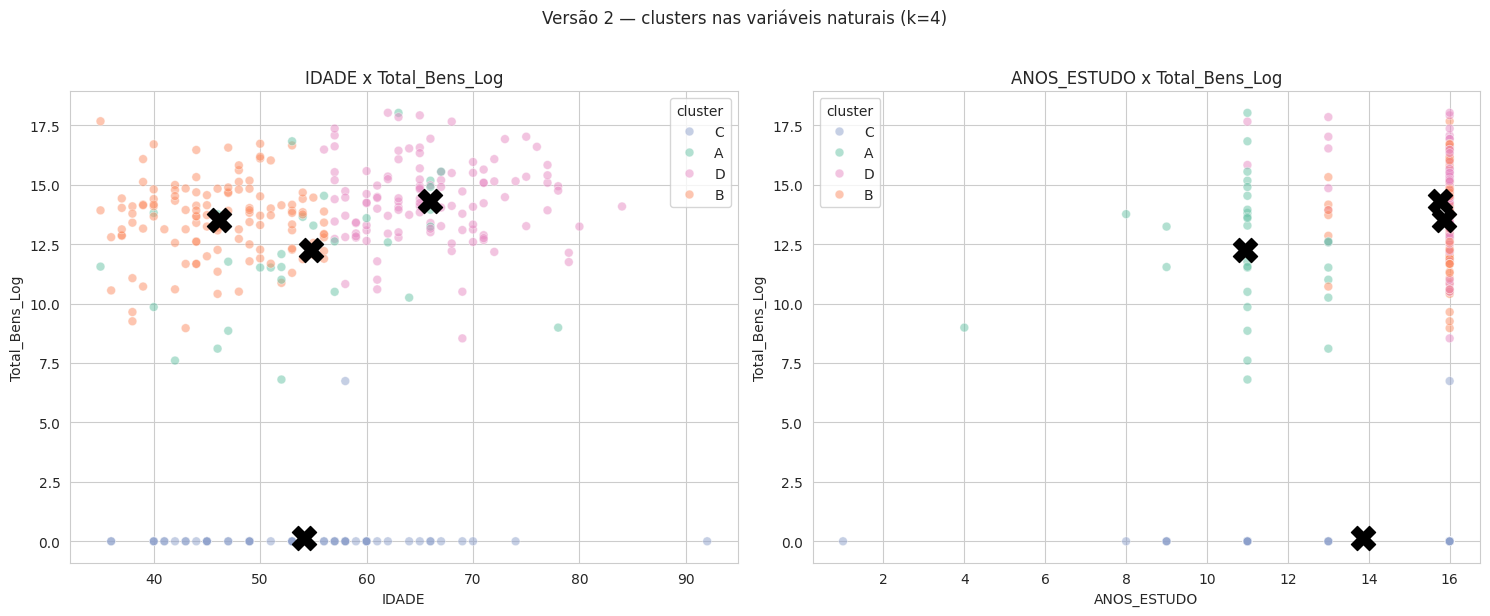

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_cluster, x='IDADE', y='Total_Bens_Log', hue='cluster', palette=cores_cluster, alpha=0.5, s=40, ax=axes[0])
axes[0].scatter(df_centroides['IDADE'], df_centroides['Total_Bens_Log'], marker='X', s=300, c='black')
axes[0].set_title('IDADE x Total_Bens_Log')

sns.scatterplot(data=df_cluster, x='ANOS_ESTUDO', y='Total_Bens_Log', hue='cluster', palette=cores_cluster, alpha=0.5, s=40, ax=axes[1])
axes[1].scatter(df_centroides['ANOS_ESTUDO'], df_centroides['Total_Bens_Log'], marker='X', s=300, c='black')
axes[1].set_title('ANOS_ESTUDO x Total_Bens_Log')

plt.suptitle(f'Versão 2 — clusters nas variáveis naturais (k={k_final})', y=1.02)
plt.tight_layout()
plt.show()

---
## Comparando Versão 1 x Versão 2

Duas coisas pra olhar lado a lado: a **métrica de qualidade** (silhouette) e o **tamanho dos grupos** — se a distribuição de candidatos por cluster mudou bastante, é sinal de que a troca de variável/métrica realmente importou.

Versão 1 (CD_GRAU_INSTRUCAO bruto), k=4: silhouette = 0.455
Versão 2 (ANOS_ESTUDO),           k=4: silhouette = 0.451


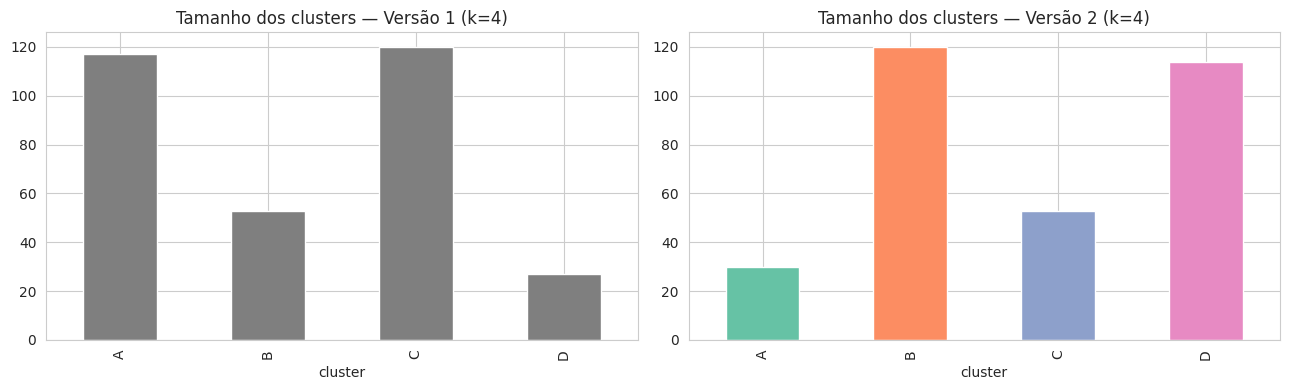

In [25]:
print(f"Versão 1 (CD_GRAU_INSTRUCAO bruto), k={k_v1}: silhouette = {sil_v1[list(faixa_k).index(k_v1)]:.3f}")
print(f"Versão 2 (ANOS_ESTUDO),           k={k_final}: silhouette = {sil[list(faixa_k).index(k_final)]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_cluster_v1['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='tab:gray')
axes[0].set_title(f'Tamanho dos clusters — Versão 1 (k={k_v1})')

contagem_v2 = df_cluster['cluster'].value_counts().sort_index()
contagem_v2.plot(kind='bar', ax=axes[1], color=[cores_cluster[c] for c in contagem_v2.index])
axes[1].set_title(f'Tamanho dos clusters — Versão 2 (k={k_final})')

plt.tight_layout()
plt.show()

---
## Perfil demográfico-social de cada cluster

A partir daqui usamos a **Versão 2** (ajustada) como resultado oficial. Primeiro pelas variáveis-driver (já visto acima), agora pelas variáveis de perfil — o que responde de fato a pergunta de negócio.

### Composição demográfica de cada cluster (variáveis de perfil)

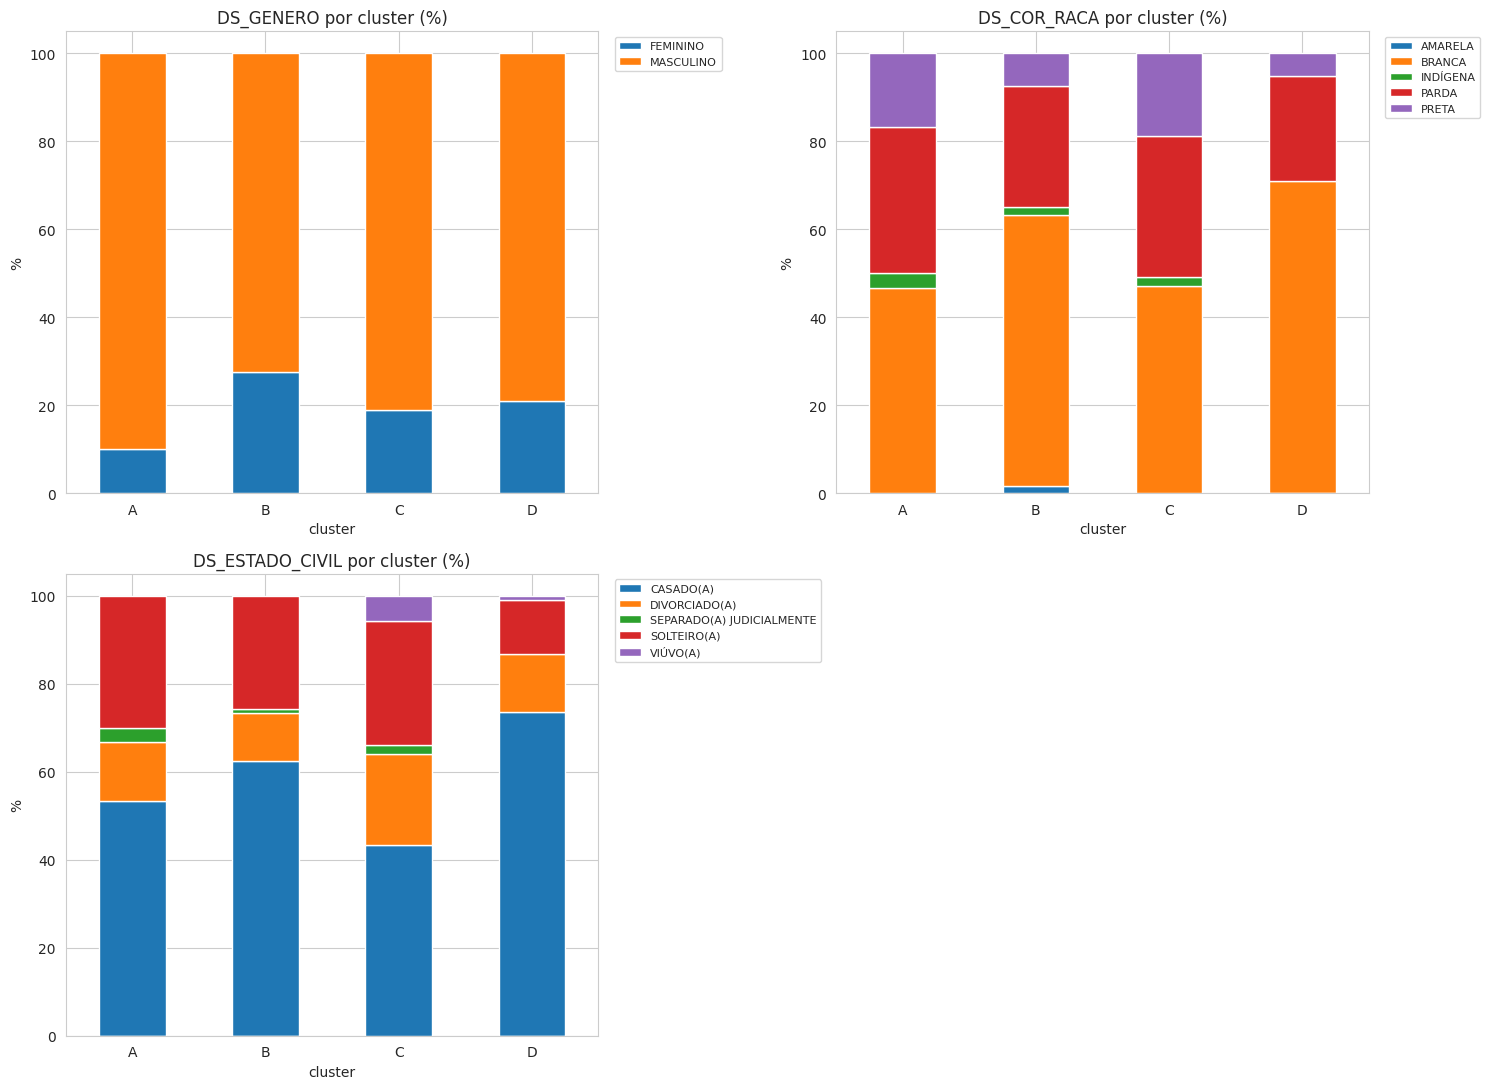

In [26]:
# DS_SIT_TOT_TURNO fica de fora por enquanto — a eleição de 2026 ainda não ocorreu,
# então essa coluna vem toda nula na base atual.
colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']
colunas_perfil = [c for c in colunas_perfil if c in df_cluster.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    pd.crosstab(df_cluster['cluster'], df_cluster[col], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=axes[i]
    )
    axes[i].set_title(f'{col} por cluster (%)')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Pizza: a composição de cada cluster, isoladamente

As barras acima comparam os clusters entre si — é a leitura mais rigorosa quando o que importa é comparar. As pizzas abaixo mostram a mesma informação de um jeito mais familiar pra quem só quer ver "como é o cluster A por dentro", uma variável e um cluster de cada vez.

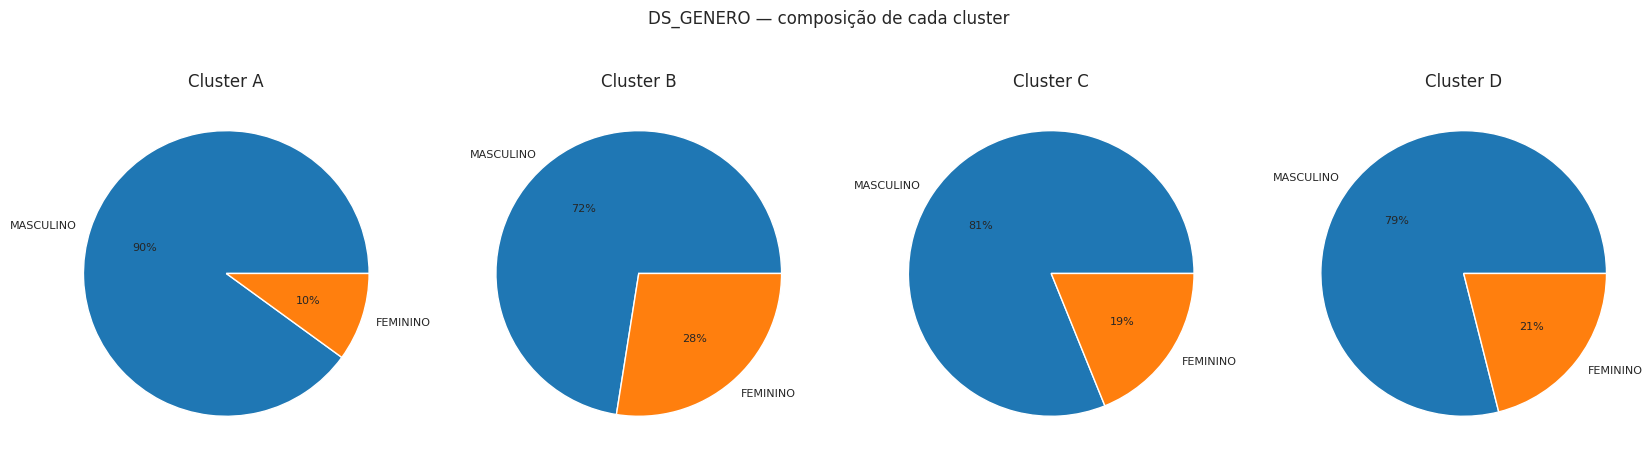

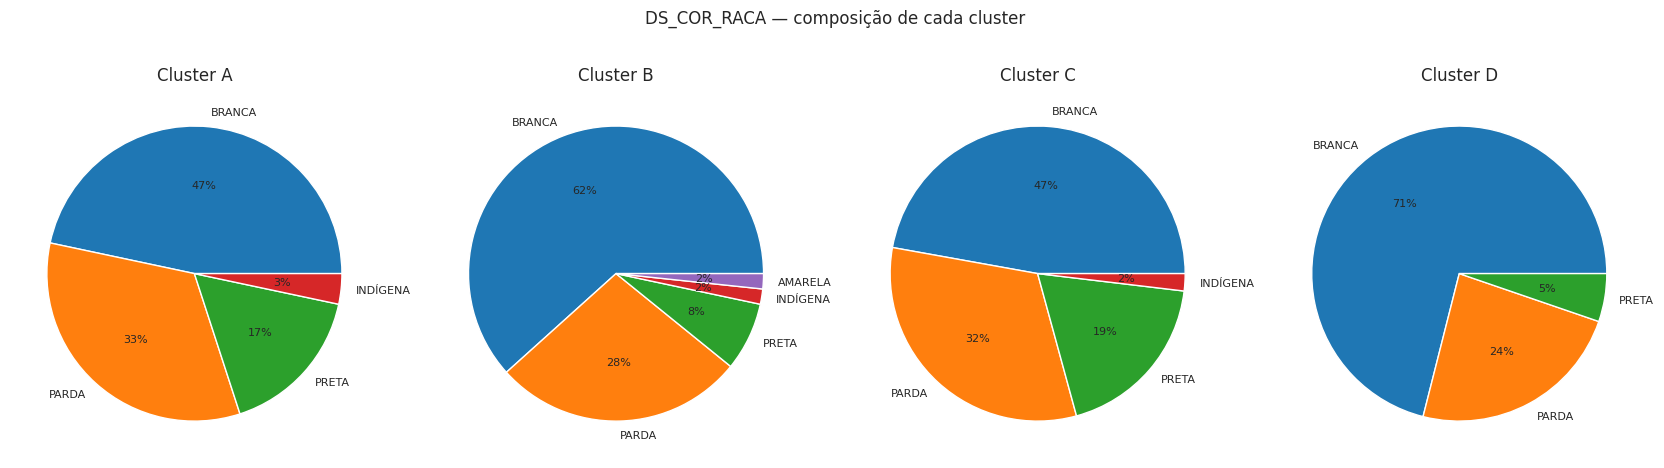

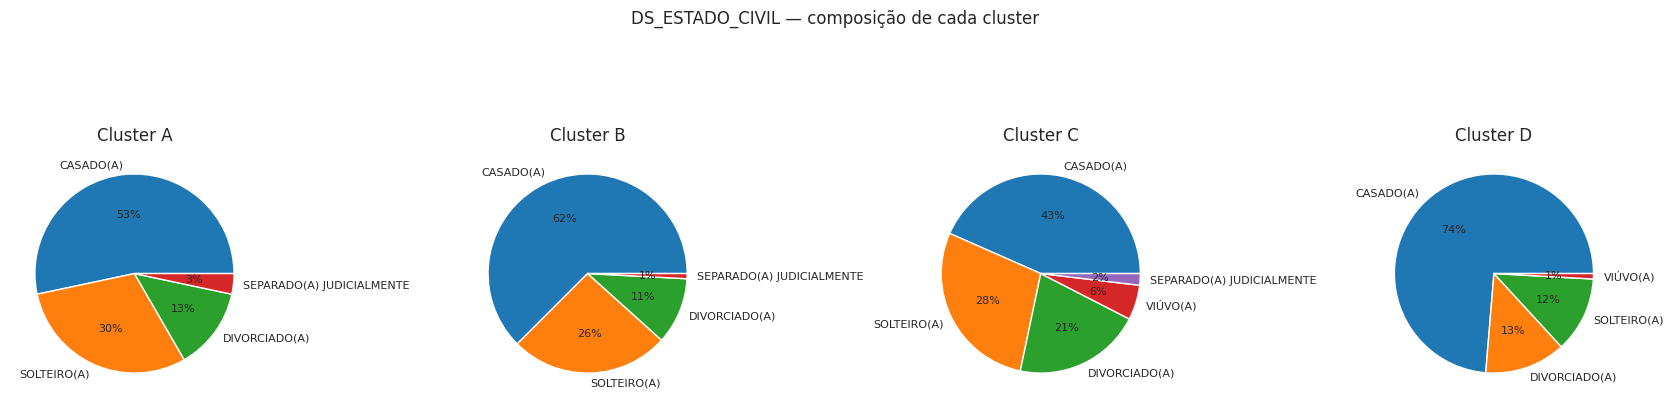

In [27]:
for col in colunas_perfil:
    fig, axes = plt.subplots(1, k_final, figsize=(4.2 * k_final, 4.5))
    if k_final == 1:
        axes = [axes]

    clusters_ordenados = sorted(df_cluster['cluster'].unique())
    for ax, cl in zip(axes, clusters_ordenados):
        contagem = df_cluster.loc[df_cluster['cluster'] == cl, col].value_counts()
        ax.pie(contagem, labels=contagem.index, autopct='%1.0f%%', textprops={'fontsize': 8})
        ax.set_title(f'Cluster {cl}')

    plt.suptitle(f'{col} — composição de cada cluster', y=1.05)
    plt.tight_layout()
    plt.show()

### Direção inversa: onde cada grupo demográfico está distribuído entre os clusters

Até aqui perguntamos "dentro do cluster X, qual a composição por gênero/cor-raça/estado civil?". Agora invertemos: **de todos os candidatos de um determinado grupo (ex.: todos os do gênero masculino), em quais clusters eles estão?** É a mesma tabela de contingência, só trocando o que normaliza — por categoria demográfica em vez de por cluster.

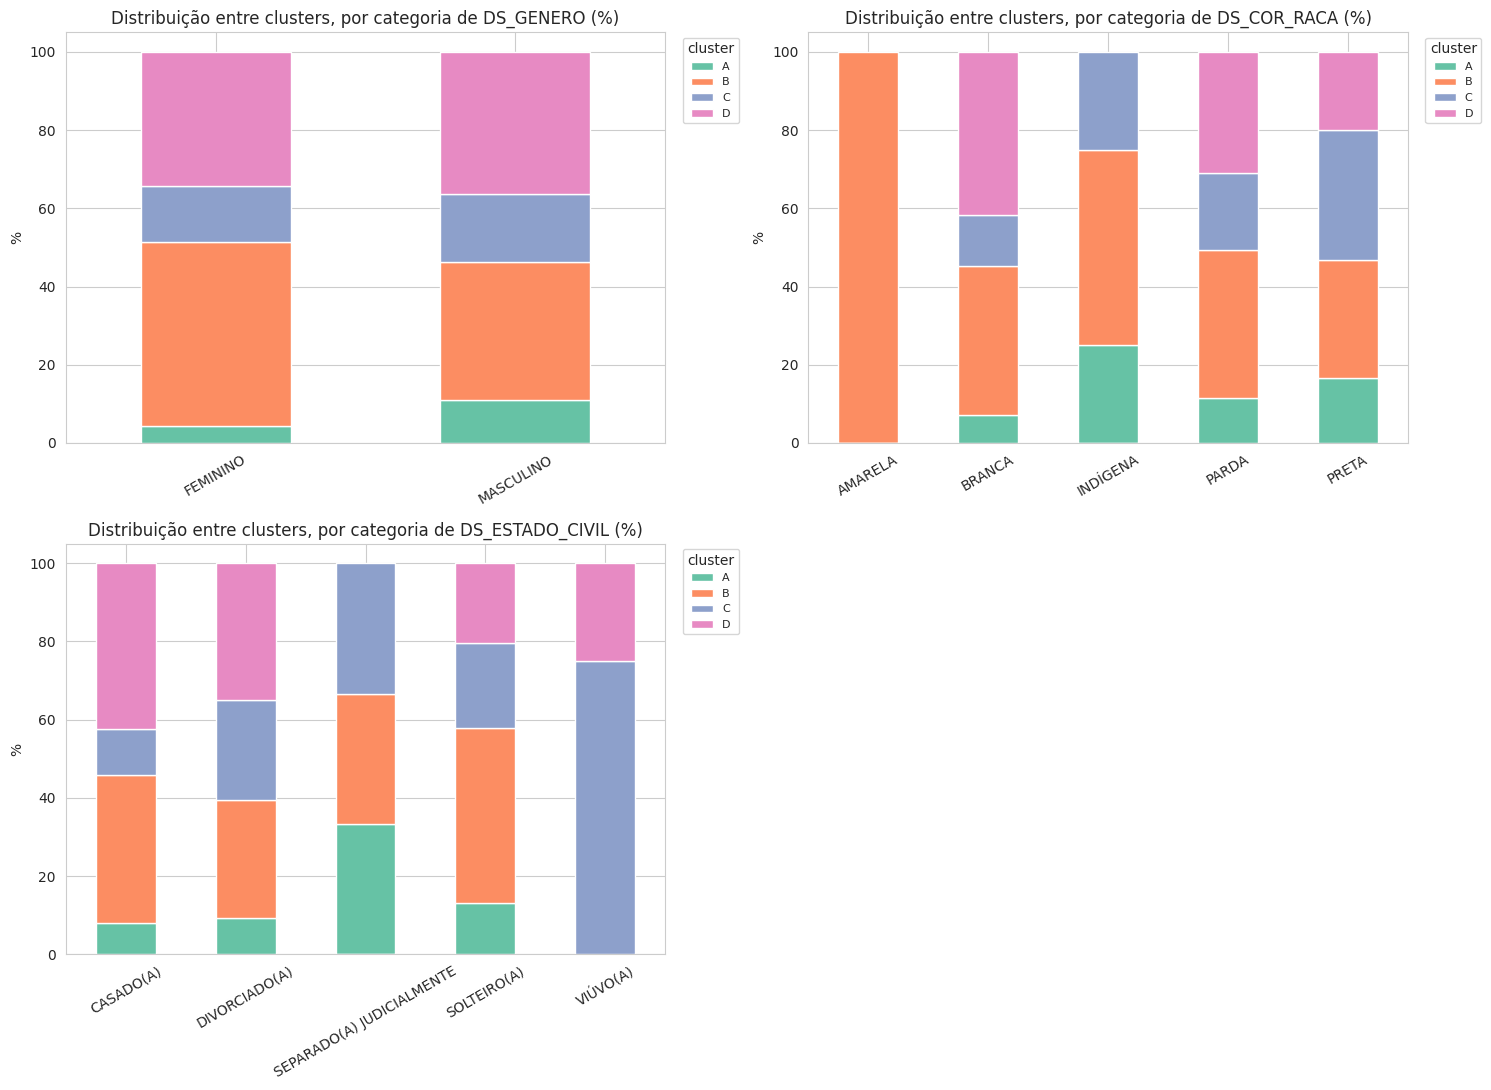

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    tabela = pd.crosstab(df_cluster[col], df_cluster['cluster'], normalize='index').mul(100)
    tabela = tabela[clusters_ordenados]  # garante a mesma ordem de colunas de cores_cluster
    tabela.plot(kind='bar', stacked=True, ax=axes[i], color=[cores_cluster[c] for c in tabela.columns])
    axes[i].set_title(f'Distribuição entre clusters, por categoria de {col} (%)')
    axes[i].set_ylabel('%')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Comparação por UF

Esta seção só roda na visão **Brasil** (quando `UF = None`).

In [29]:
if UF is None:
    composicao_uf = pd.crosstab(df_cluster['SG_UF'], df_cluster['cluster'], normalize='index').mul(100).round(1)
    display(composicao_uf)
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")

cluster,A,B,C,D
SG_UF,,,,
AC,12.5,50.0,12.5,25.0
AL,0.0,28.6,28.6,42.9
AM,11.1,44.4,22.2,22.2
AP,0.0,55.6,33.3,11.1
BA,10.0,30.0,10.0,50.0
CE,0.0,37.5,12.5,50.0
DF,0.0,30.8,23.1,46.2
ES,9.1,45.5,0.0,45.5
GO,9.1,54.5,9.1,27.3


---
## Respondendo à pergunta de negócio: nomeando os clusters

Esta é a etapa mais importante de toda a análise — é aqui que o K-Means (que só enxerga números) vira uma resposta que faz sentido pra gente. Três ferramentas de apoio, dos números pro nome:

1. **Ficha técnica**: uma tabela única por cluster, juntando drivers e perfil.
2. **O que destaca cada cluster**: um heatmap mostrando só o que foge da média geral — o "diferencial" de cada grupo.
3. **Rascunho automático**: um parágrafo gerado a partir da ficha técnica, pra vocês editarem em vez de escreverem do zero.

### 1) Ficha técnica por cluster

In [30]:
ficha = df_cluster.groupby('cluster').agg(
    qtd=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
ficha['pct_do_total'] = (ficha['qtd'] / ficha['qtd'].sum() * 100).round(1)

for col in colunas_perfil:
    ficha[f'{col}_predominante'] = df_cluster.groupby('cluster')[col].agg(lambda s: s.mode().iat[0])
    ficha[f'{col}_pct'] = df_cluster.groupby('cluster')[col].apply(
        lambda s: (s == s.mode().iat[0]).mean() * 100
    ).round(1)

ficha

,qtd,idade_media,anos_estudo_medio,patrimonio_mediano,pct_do_total,DS_GENERO_predominante,DS_GENERO_pct,DS_COR_RACA_predominante,DS_COR_RACA_pct,DS_ESTADO_CIVIL_predominante,DS_ESTADO_CIVIL_pct
cluster,,,,,,,,,,,
A,30,54.7,10.9,232000.0,9.5,MASCULINO,90.0,BRANCA,46.7,CASADO(A),53.3
B,120,46.2,15.8,920662.2,37.9,MASCULINO,72.5,BRANCA,61.7,CASADO(A),62.5
C,53,54.1,13.9,0.0,16.7,MASCULINO,81.1,BRANCA,47.2,CASADO(A),43.4
D,114,66.0,15.8,1684036.7,36.0,MASCULINO,78.9,BRANCA,71.1,CASADO(A),73.7


### 2) O que destaca cada cluster (desvio em relação à média geral)

Quanto mais forte a cor (positiva ou negativa), mais aquele cluster se afasta da média geral de candidatos naquela variável — é isso que normalmente vira o "nome" do cluster.

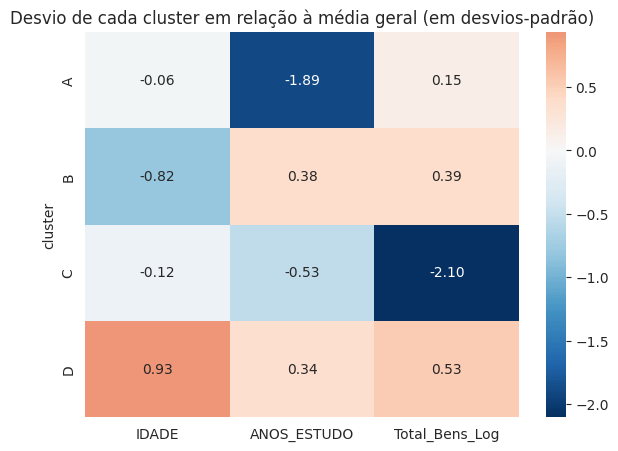

In [31]:
medias_gerais = df_cluster[colunas_driver].mean()
desvios_gerais = df_cluster[colunas_driver].std()
medias_cluster = df_cluster.groupby('cluster')[colunas_driver].mean()

zscore_cluster = (medias_cluster - medias_gerais) / desvios_gerais

plt.figure(figsize=(7, 1 + k_final))
sns.heatmap(zscore_cluster, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Desvio de cada cluster em relação à média geral (em desvios-padrão)')
plt.xlabel('')
plt.ylabel('cluster')
plt.show()

### 3) Rascunho automático — editem à vontade

In [32]:
for cl in clusters_ordenados:
    linha = ficha.loc[cl]
    print(f"Cluster {cl}  ({linha['qtd']:.0f} candidatos, {linha['pct_do_total']:.0f}% do total)")
    print(f"  Idade média: {linha['idade_media']:.0f} anos | Escolaridade média: {linha['anos_estudo_medio']:.0f} anos de estudo "
          f"| Patrimônio mediano: R$ {linha['patrimonio_mediano']:,.0f}")
    for col in colunas_perfil:
        print(f"  Predominância em {col}: {linha[f'{col}_predominante']} ({linha[f'{col}_pct']:.0f}%)")
    print(f"  >> Nome sugerido: _______________________")
    print()

Cluster A  (30 candidatos, 10% do total)
  Idade média: 55 anos | Escolaridade média: 11 anos de estudo | Patrimônio mediano: R$ 232,000
  Predominância em DS_GENERO: MASCULINO (90%)
  Predominância em DS_COR_RACA: BRANCA (47%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (53%)
  >> Nome sugerido: _______________________

Cluster B  (120 candidatos, 38% do total)
  Idade média: 46 anos | Escolaridade média: 16 anos de estudo | Patrimônio mediano: R$ 920,662
  Predominância em DS_GENERO: MASCULINO (72%)
  Predominância em DS_COR_RACA: BRANCA (62%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (62%)
  >> Nome sugerido: _______________________

Cluster C  (53 candidatos, 17% do total)
  Idade média: 54 anos | Escolaridade média: 14 anos de estudo | Patrimônio mediano: R$ 0
  Predominância em DS_GENERO: MASCULINO (81%)
  Predominância em DS_COR_RACA: BRANCA (47%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (43%)
  >> Nome sugerido: _______________________

Cluster D  (114 candidatos, 36

### Nomes finais dos clusters (K-Means)

Preencham com base nas três ferramentas acima:

- **Cluster A:** ...
- **Cluster B:** ...
- **Cluster C:** ...
- **Cluster D:** ...

---
# Parte 2 — Bisecting K-Means

**A ideia:** em vez de escolher um `k` e rodar o K-Means uma vez, o Bisecting K-Means começa com **1 cluster (todo mundo)** e vai dividindo em 2 repetidamente — a cada passo, escolhe **um** cluster já existente e o quebra em 2, aumentando `k` em 1 de cada vez (1→2→3→4→...).

O scikit-learn tem `BisectingKMeans`, mas ele só devolve o resultado final — não expõe **qual cluster foi escolhido em cada divisão**, que é exatamente o que você quer enxergar. Por isso implementamos o algoritmo manualmente aqui: a cada passo, guardamos qual cluster foi dividido, o tamanho dele e sua inércia, o que nos dá:

1. **A árvore de divisões** — literalmente o que você pediu para enxergar.
2. **Um critério de parada visual**: enquanto o algoritmo estiver dividindo clusters **grandes**, cada divisão ainda separa bastante gente diferente — informação nova. Quando ele passa a dividir clusters **pequenos**, é sinal de que os grupos grandes e relevantes já foram encontrados, e o que resta é só "aparar as bordas". O gráfico de tamanho por nível, abaixo, mostra exatamente esse ponto de virada.

Usamos a mesma base da Versão 2 (`X`, já padronizada e sem outliers) para ficar diretamente comparável ao K-Means.

### 1) Implementação manual, guardando o histórico de divisões

In [33]:
def bisecting_kmeans_com_historico(X, k_max, criterio='tamanho', random_state=SEMENTE):
    """
    Roda o Bisecting K-Means manualmente até k_max clusters, guardando o histórico
    de cada divisão (qual cluster foi escolhido, tamanho, inércia).

    criterio:
      'tamanho'  -> a cada passo, divide o cluster com MAIS pontos
      'inercia'  -> a cada passo, divide o cluster com MAIOR inércia (WCSS) interna
                    (é o padrão do sklearn.cluster.BisectingKMeans)
    """
    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        return float(((pontos - centro) ** 2).sum())

    clusters = {0: np.arange(X.shape[0])}   # cluster raiz = todos os pontos
    historico = []
    proximo_id = 1

    for nivel in range(1, k_max):
        if criterio == 'tamanho':
            id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        else:
            id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))

        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        filho_a = indices_pai[labels2 == 0]
        filho_b = indices_pai[labels2 == 1]

        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2

        historico.append({
            'k_resultante': nivel + 1,
            'pai_id': id_escolhido, 'pai_tamanho': len(indices_pai), 'pai_inercia': inercia(indices_pai),
            'filho_a_id': id_a, 'filho_a_tamanho': len(filho_a),
            'filho_b_id': id_b, 'filho_b_tamanho': len(filho_b),
        })

        del clusters[id_escolhido]
        clusters[id_a] = filho_a
        clusters[id_b] = filho_b

    return clusters, historico

k_max_bisecting = max(faixa_k) + 1  # mesma faixa usada no K-Means (até 20)
clusters_finais, historico_bisecting = bisecting_kmeans_com_historico(X, k_max_bisecting, criterio='tamanho')

print(f"Divisões realizadas: {len(historico_bisecting)}  (de k=1 até k={k_max_bisecting})")

Divisões realizadas: 19  (de k=1 até k=20)


### 1.1) `'tamanho'` x `'inercia'`: o critério muda a ordem das divisões?

Com `criterio='tamanho'`, o algoritmo **sempre** escolhe o cluster com mais pontos — é a definição do critério, não um efeito colateral. Isso ignora se aquele cluster já está "compacto" (baixa inércia — pouco a ganhar em dividir) ou muito espalhado (alta inércia — muito a ganhar). O padrão do `sklearn.cluster.BisectingKMeans` é `'inercia'`, não `'tamanho'`. Vamos rodar os dois e comparar diretamente se isso muda a ordem das divisões neste dataset.

In [34]:
_, historico_inercia = bisecting_kmeans_com_historico(X, k_max_bisecting, criterio='inercia')

comparacao_criterios = pd.DataFrame({
    'k': [h['k_resultante'] for h in historico_bisecting],
    'pai_escolhido_por_tamanho': [h['pai_id'] for h in historico_bisecting],
    'pai_escolhido_por_inercia': [h['pai_id'] for h in historico_inercia],
})
comparacao_criterios['mesma_escolha'] = comparacao_criterios['pai_escolhido_por_tamanho'] == comparacao_criterios['pai_escolhido_por_inercia']

qtd_iguais = comparacao_criterios['mesma_escolha'].sum()
print(f"Nos {len(comparacao_criterios)} níveis, os dois critérios escolheram o mesmo cluster para dividir em {qtd_iguais} deles "
      f"({qtd_iguais / len(comparacao_criterios):.0%}).")
display(comparacao_criterios)

Nos 19 níveis, os dois critérios escolheram o mesmo cluster para dividir em 4 deles (21%).


,k,pai_escolhido_por_tamanho,pai_escolhido_por_inercia,mesma_escolha
0,2,0,0,True
1,3,2,2,True
2,4,4,1,False
3,5,3,3,True
4,6,5,4,False
5,7,8,8,True
6,8,12,9,False
7,9,9,6,False
8,10,1,5,False
9,11,10,7,False


Se a coluna `mesma_escolha` for `True` na maior parte das linhas, os dois critérios levam praticamente à mesma árvore neste dataset (tamanho e inércia estão correlacionados aqui). Se divergir bastante, vale a pena trocar `criterio='tamanho'` para `criterio='inercia'` na célula anterior e rodar o restante do notebook de novo — a árvore, a animação e os gráficos abaixo vão refletir a nova ordem de divisões.

### 2) Quando parar? Tamanho e inércia do cluster escolhido, a cada nível

Procure o ponto em que a curva despenca — é onde o algoritmo para de dividir clusters relevantes e passa a dividir sobras.

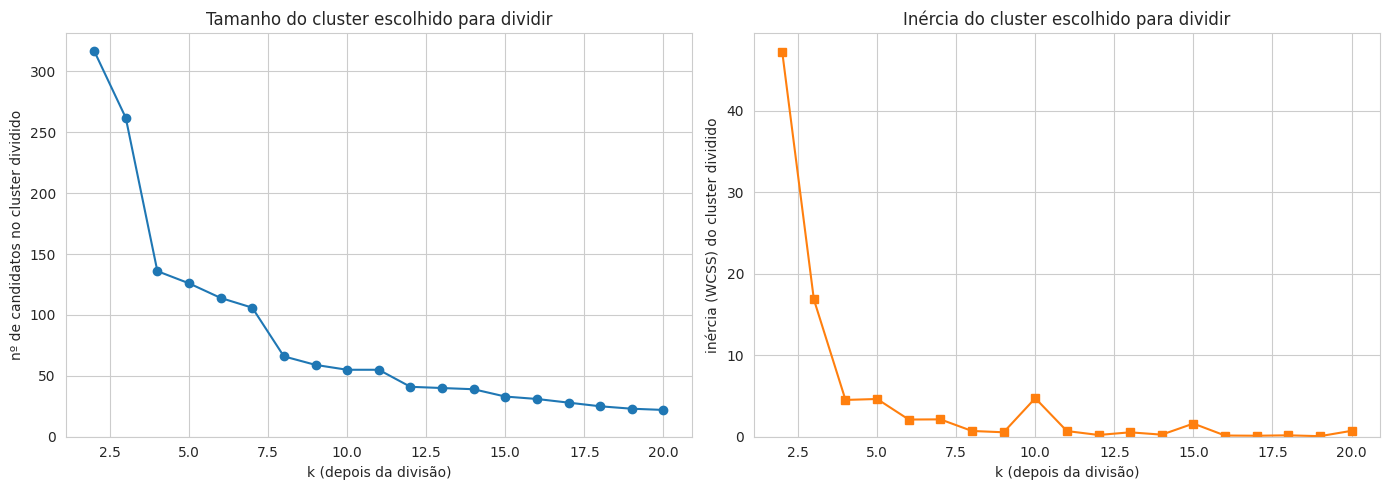

In [35]:
k_resultante = [h['k_resultante'] for h in historico_bisecting]
tamanho_escolhido = [h['pai_tamanho'] for h in historico_bisecting]
inercia_escolhida = [h['pai_inercia'] for h in historico_bisecting]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_resultante, tamanho_escolhido, marker='o')
axes[0].set_title('Tamanho do cluster escolhido para dividir')
axes[0].set_xlabel('k (depois da divisão)')
axes[0].set_ylabel('nº de candidatos no cluster dividido')
axes[0].set_ylim(bottom=0)
axes[0].grid(True)

axes[1].plot(k_resultante, inercia_escolhida, marker='s', color='tab:orange')
axes[1].set_title('Inércia do cluster escolhido para dividir')
axes[1].set_xlabel('k (depois da divisão)')
axes[1].set_ylabel('inércia (WCSS) do cluster dividido')
axes[1].set_ylim(bottom=0)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3) A árvore de divisões

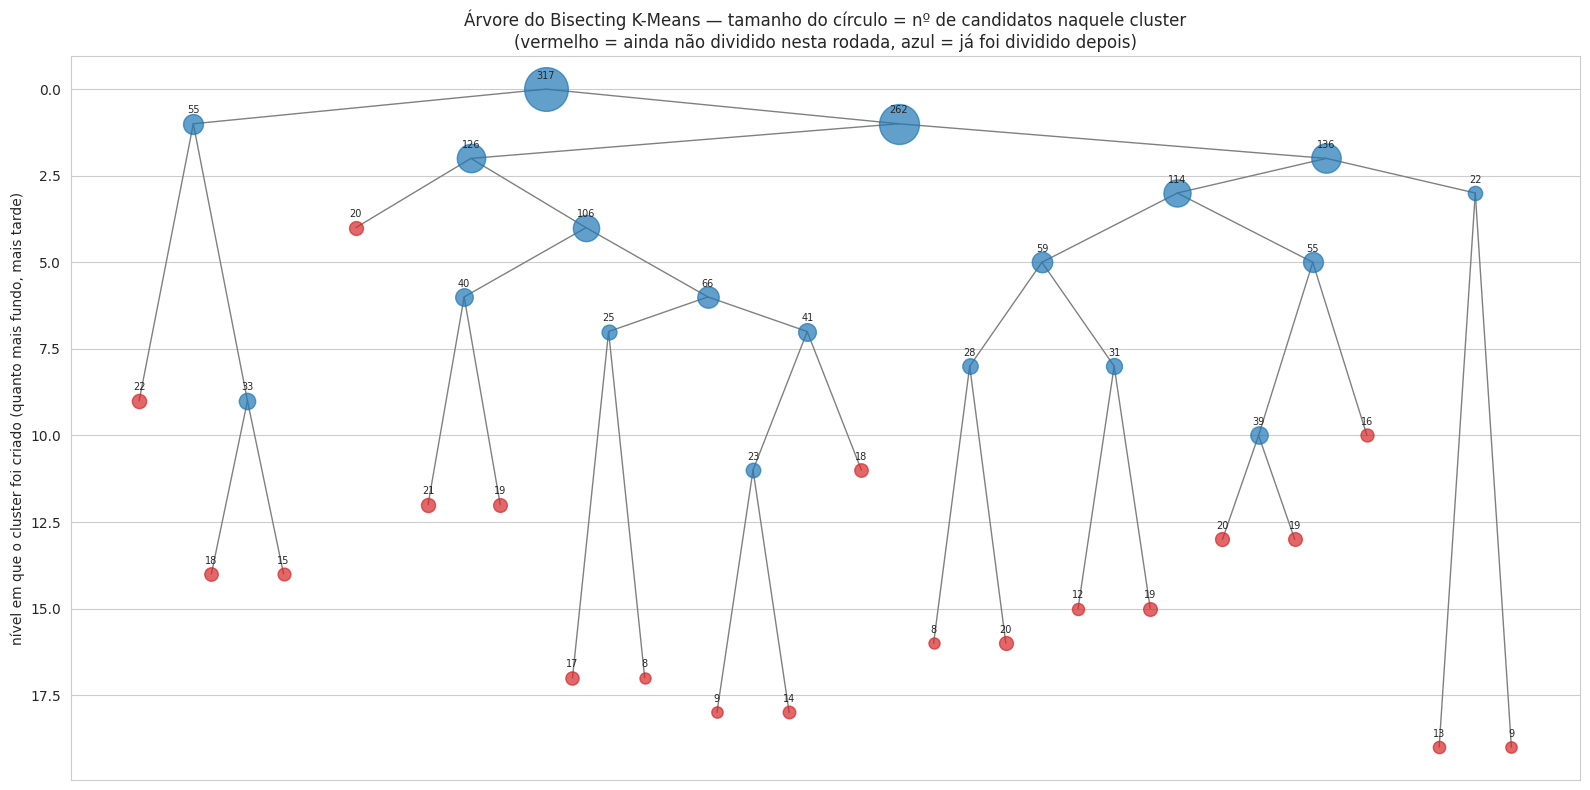

In [36]:
nos = {0: {'pai': None, 'nivel': 0, 'tamanho': X.shape[0], 'filhos': None}}
for h in historico_bisecting:
    nos[h['pai_id']]['filhos'] = [h['filho_a_id'], h['filho_b_id']]
    nos[h['filho_a_id']] = {'pai': h['pai_id'], 'nivel': h['k_resultante'] - 1, 'tamanho': h['filho_a_tamanho'], 'filhos': None}
    nos[h['filho_b_id']] = {'pai': h['pai_id'], 'nivel': h['k_resultante'] - 1, 'tamanho': h['filho_b_tamanho'], 'filhos': None}

# posição horizontal: folhas em ordem, nós internos = média dos filhos (layout clássico de árvore)
posicoes = {}
_x = [0]

def atribuir_x(no_id):
    filhos = nos[no_id]['filhos']
    if filhos is None:
        posicoes[no_id] = _x[0]
        _x[0] += 1
    else:
        for f in filhos:
            atribuir_x(f)
        posicoes[no_id] = sum(posicoes[f] for f in filhos) / len(filhos)

atribuir_x(0)

plt.figure(figsize=(16, 8))
for no_id, info in nos.items():
    if info['filhos']:
        for f in info['filhos']:
            plt.plot([posicoes[no_id], posicoes[f]], [info['nivel'], nos[f]['nivel']],
                      color='gray', linewidth=1, zorder=1)

for no_id, info in nos.items():
    e_folha = info['filhos'] is None
    plt.scatter(posicoes[no_id], info['nivel'], s=40 + info['tamanho'] * 3,
                color='tab:red' if e_folha else 'tab:blue', alpha=0.7, zorder=2)
    plt.text(posicoes[no_id], info['nivel'] - 0.3, str(info['tamanho']), ha='center', fontsize=7)

plt.gca().invert_yaxis()
plt.ylabel('nível em que o cluster foi criado (quanto mais fundo, mais tarde)')
plt.xticks([])
plt.title('Árvore do Bisecting K-Means — tamanho do círculo = nº de candidatos naquele cluster\n(vermelho = ainda não dividido nesta rodada, azul = já foi dividido depois)')
plt.tight_layout()
plt.show()

### 3.1) Animação: a árvore crescendo, nível a nível

A árvore estática fica poluída com muitos níveis de uma vez. Esta animação mostra **a mesma árvore**, mas revelando um nível por vez — a cada frame, um nó vermelho (folha ainda não dividida) "explode" em dois, e vira azul. As posições dos nós são as mesmas da árvore estática (calculadas uma vez só), então nada pula de lugar entre frames — só aparece o que é novo.

In [37]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

historico_por_k = {h['k_resultante']: h for h in historico_bisecting}
ks_disponiveis = list(range(1, max(historico_por_k) + 1))

def estado_arvore_no_k(k):
    """Quais nós já existem, e quais deles ainda são folha (não foram divididos), no frame k."""
    existentes = [nid for nid, info in nos.items() if info['nivel'] <= k - 1]
    set_existentes = set(existentes)
    folhas = []
    for nid in existentes:
        filhos = nos[nid]['filhos']
        if filhos is None or filhos[0] not in set_existentes:
            folhas.append(nid)
    return existentes, set(folhas)

max_nivel = max(info['nivel'] for info in nos.values())
x_min, x_max = min(posicoes.values()), max(posicoes.values())

fig, ax = plt.subplots(figsize=(16, 8))

def desenhar_frame_arvore(k):
    ax.clear()
    existentes, folhas = estado_arvore_no_k(k)
    set_existentes = set(existentes)

    for nid in existentes:
        filhos = nos[nid]['filhos']
        if filhos:
            for f in filhos:
                if f in set_existentes:
                    ax.plot([posicoes[nid], posicoes[f]], [nos[nid]['nivel'], nos[f]['nivel']],
                            color='gray', linewidth=1, zorder=1)

    for nid in existentes:
        info = nos[nid]
        cor = 'tab:red' if nid in folhas else 'tab:blue'
        ax.scatter(posicoes[nid], info['nivel'], s=40 + info['tamanho'] * 3, color=cor, alpha=0.7, zorder=2)
        ax.text(posicoes[nid], info['nivel'] - 0.3, str(info['tamanho']), ha='center', fontsize=7)

    ax.set_xlim(x_min - 1, x_max + 1)
    ax.set_ylim(max_nivel + 1, -1)  # eixo fixo e invertido (raiz no topo), sem "pulos" entre frames
    ax.set_xticks([])
    ax.set_ylabel('nível em que o cluster foi criado')
    if k in historico_por_k:
        h = historico_por_k[k]
        ax.set_title(f'Árvore do Bisecting K-Means — k={k}  (dividiu um cluster de {h["pai_tamanho"]} candidatos)')
    else:
        ax.set_title(f'Árvore do Bisecting K-Means — k={k} (estado inicial, 1 cluster só)')

anim = FuncAnimation(fig, desenhar_frame_arvore, frames=ks_disponiveis, interval=800, repeat=True)
plt.close(fig)  # evita mostrar também uma figura estática duplicada, além da animação
HTML(anim.to_jshtml())

> Se a animação demorar pra renderizar (muitos frames), aumente `interval` (ela roda mais devagar) ou reduza `k_max_bisecting` mais acima. Pra usar fora do notebook (ex.: num slide): `anim.save('arvore_bisecting.gif', writer='pillow')`.

### 4) Escolhendo k e extraindo o resultado final

Com base nos dois gráficos acima (tamanho/inércia por nível + a árvore), escolha um `k` — é o ponto em que dividir deixou de parecer valer a pena.

In [38]:
k_bisecting = 4  # ajuste conforme as duas seções anteriores

# Reconstrói a partição em k_bisecting clusters, refazendo as divisões do histórico até esse ponto.
# Refazer o KMeans(n_clusters=2) é determinístico (mesma SEMENTE, mesmos dados de entrada),
# então dá exatamente a mesma divisão já registrada — sem precisar guardar todos os índices no histórico.
clusters_no_k = {0: np.arange(X.shape[0])}
for h in historico_bisecting:
    if h['k_resultante'] > k_bisecting:
        break
    indices_pai = clusters_no_k.pop(h['pai_id'])
    km2 = KMeans(n_clusters=2, random_state=SEMENTE, n_init=10)
    labels2 = km2.fit_predict(X[indices_pai])
    clusters_no_k[h['filho_a_id']] = indices_pai[labels2 == 0]
    clusters_no_k[h['filho_b_id']] = indices_pai[labels2 == 1]

# transformar em uma coluna de cluster no df_cluster (rótulos A, B, C... por ordem de tamanho)
ids_por_tamanho = sorted(clusters_no_k, key=lambda cid: len(clusters_no_k[cid]), reverse=True)
df_cluster['cluster_bisecting'] = ''
for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
    df_cluster.iloc[clusters_no_k[cid], df_cluster.columns.get_loc('cluster_bisecting')] = letra

df_cluster['cluster_bisecting'].value_counts().sort_index()

,count
cluster_bisecting,
A,126
B,114
C,55
D,22


### 5) Comparando com o K-Means (Versão 2)

Silhouette — K-Means (V2, k=4):        0.451
Silhouette — Bisecting K-Means (k=4): 0.420


,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster_bisecting,,,,
A,126,65.8,15.3,1563358.3
B,114,46.4,16.0,916381.6
C,55,53.8,13.8,0.0
D,22,46.5,11.6,152000.0


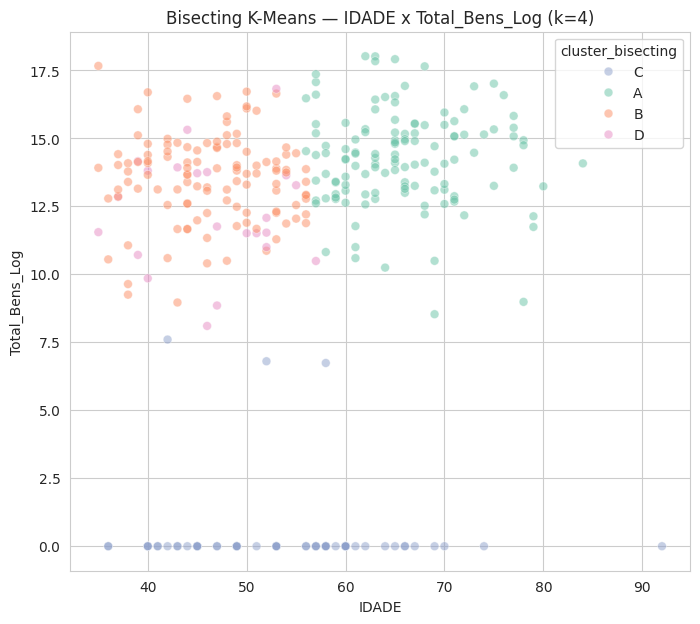

In [39]:
labels_bisecting = df_cluster['cluster_bisecting'].values
print(f"Silhouette — K-Means (V2, k={k_final}):        {silhouette_score(X, df_cluster['cluster']):.3f}")
print(f"Silhouette — Bisecting K-Means (k={k_bisecting}): {silhouette_score(X, labels_bisecting):.3f}")

resumo_bisecting = df_cluster.groupby('cluster_bisecting').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_bisecting)

clusters_bisecting_ordenados = sorted(df_cluster['cluster_bisecting'].unique())
cores_bisecting = dict(zip(clusters_bisecting_ordenados, sns.color_palette('Set2', n_colors=len(clusters_bisecting_ordenados))))

plt.figure(figsize=(8, 7))
sns.scatterplot(data=df_cluster, x='IDADE', y='Total_Bens_Log', hue='cluster_bisecting', palette=cores_bisecting, alpha=0.5, s=40)
plt.title(f'Bisecting K-Means — IDADE x Total_Bens_Log (k={k_bisecting})')
plt.show()

**Interpretação:** compare o `resumo_bisecting` com o `resumo_driver` do K-Means e a silhouette dos dois. Se os grupos ficarem parecidos, é um bom sinal de que a estrutura é real (dois algoritmos diferentes concordando); se ficarem bem diferentes, vale a pena entender por quê — o K-Means busca uma solução global pra todo o `k` de uma vez, enquanto o Bisecting constrói de forma incremental, e pode ficar "preso" a decisões tomadas em níveis anteriores.

O mesmo kit de nomeação da Parte 1 (ficha técnica, heatmap de desvio, rascunho automático) pode ser reaplicado aqui trocando `cluster` por `cluster_bisecting` nas agregações — fica como exercício.

---
## Fechamento e próximos passos

Duas famílias de algoritmo até aqui:

- **K-Means (Parte 1)**, em duas rodadas — mostrando o efeito de tratar uma variável ordinal como intervalar, e de usar mais de uma métrica pra escolher `k`.
- **Bisecting K-Means (Parte 2)** — construção incremental e visual, com uma árvore mostrando a ordem das divisões e um critério de parada baseado em quando parar de dividir clusters grandes.

Na próxima atualização: **DBSCAN** e **clusterização hierárquica**, reaproveitando a mesma base e a mesma pergunta de negócio.